In [1]:
# LIBRARIES AND SETTINGS
import numpy as np
import torch
from scipy.ndimage import gaussian_filter  
import matplotlib.pyplot as plt
import deepwave
from deepwave import scalar           # used to perform the forward modelling

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')       # to use the GPU if available
#device = torch.device('cpu')  # to use the cpu

# LOAD THE DATA
ny = 2301
nx = 751
vp = torch.from_file('marmousi_vp.bin',                            # Load the Marmousi velocity model
                         size=ny*nx).reshape(ny, nx).to(device)

# REDUCE THE VELOCITY MODEL SIZE
factor = 5   # Smoothing and subsampling factor
vp_np = vp.detach().cpu().numpy()
vp_smooth = gaussian_filter(vp_np, sigma=factor)

# Subsample
vp_reduced = vp_smooth[::factor, ::factor]
ny, nx = vp_reduced.shape   # New dimensions
dx, dy = 4.0 * factor, 4.0 * factor   #   4*5=20 m   #spacing in m

# Extent for models plotting
x_max = (ny - 1) * dx
z_max = (nx - 1) * dy
extent = [0, x_max, z_max, 0]

# TRUE VELOCITY MODEL
v_true = torch.from_numpy(vp_reduced).to(device)

# INITIAL VELOCITY MODEL (SMOOTHED TRUE MODEL)
v_init = (torch.tensor(1/gaussian_filter(1/v_true.cpu(), 25))
          .to(device))

# The smoothed velocity in another variable 
v1 = v_init.clone()   # This will be updated during FWI


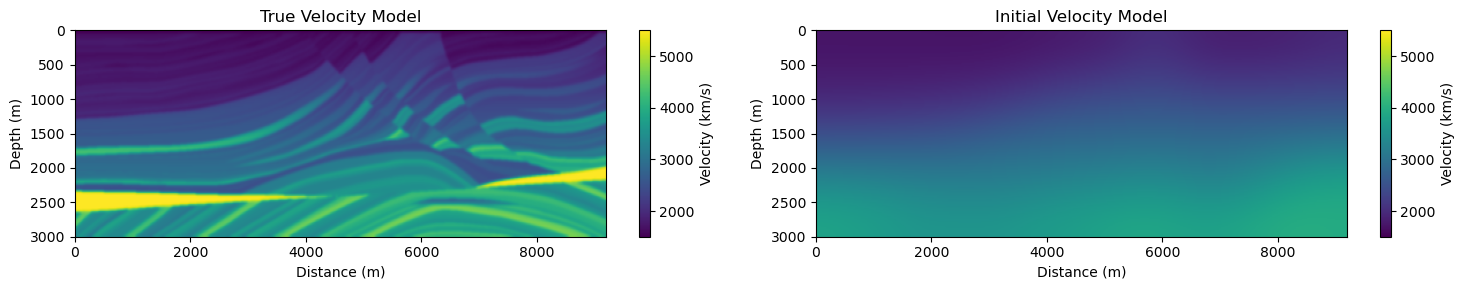

In [2]:
# PLOTTING THE TRUE AND INITIAL VELOCITY MODELS
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 3))
im1 = ax1.imshow(v_true.cpu().T, cmap='viridis', aspect='auto', vmin=v_true.min(), vmax=v_true.max(), extent=extent)
ax1.set_title('True Velocity Model')
ax1.set_xlabel('Distance (m)')
ax1.set_ylabel('Depth (m)')

im2 = ax2.imshow(v_init.cpu().T, cmap='viridis', aspect='auto', vmin=v_true.min(), vmax=v_true.max(), extent=extent)
ax2.set_title('Initial Velocity Model')
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Depth (m)')

fig1.colorbar(im1, ax=ax1, label='Velocity (km/s)')
fig1.colorbar(im2, ax=ax2, label='Velocity (km/s)')


plt.tight_layout()
plt.show()

In [3]:
# SOURCES
n_shots = 10
n_sources_per_shot = 1      
source_depth = 1         # 2 grid points * 4m = 8 m

# RECEIVERS
n_receivers_per_shot = 93     # Channels
receiver_depth = 1       # 2 * 4m = 8m

# PARAMETERS OF THE WAVELET 
freq = 5                 # Frequency of the wavelet in Hz
nt = 1350                # Number of time samples
dt = 0.004               # Sampling interval
peak_time = 1.5/freq

# SOURCE LOCATIONS
source_loc = torch.zeros(n_shots, n_sources_per_shot, 2,
                         dtype = torch.long, device = device)    
source_loc[..., 1] = source_depth
source_loc[:, 0, 0] = torch.linspace(0, ny - 1, n_shots).round()

# RECEIVERS LOCATIONS
receiver_loc = torch.zeros(n_shots, n_receivers_per_shot, 2, dtype=torch.long, device=device)
receiver_loc[..., 1] = receiver_depth
receiver_loc[:, :, 0] = torch.linspace(0, ny - 1, n_receivers_per_shot).round()


# SOURCE AMPLITUDES - RICKER WAVELET - 5 Hz
source_amp = (
            deepwave.wavelets.ricker(freq, nt, dt, peak_time)
            .repeat(n_shots, n_sources_per_shot, 1)
            .to(device)
            )

# FORWARD MODELLING FOR THE ACOUSTIC WAVE EQUATION
out_vel = scalar(v_true, dx, dt, source_amplitudes= source_amp,
                 source_locations= source_loc, receiver_locations= receiver_loc,
                 accuracy=4, pml_freq= freq)

observed_data = out_vel[-1]  # located in the last tensor of the output of the forward model

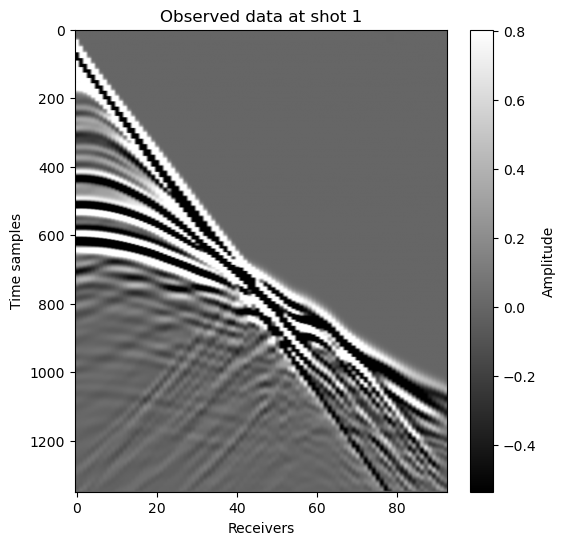

<Figure size 640x480 with 0 Axes>

In [ ]:
# PLOTTING THE OBSERVED DATA
shot_idx = 0
amin, amax = torch.quantile(observed_data[shot_idx], 
                            torch.tensor([0.05, 0.95]).to(device))
plt.figure(figsize=(6, 6))
plt.imshow(observed_data[shot_idx].cpu().T, cmap='gray', aspect='auto', vmin=amin, vmax=amax)
plt.xlabel('Receivers') ; plt.ylabel('Time samples')
plt.colorbar(label='Amplitude')
plt.title(f'Observed data at shot {shot_idx + 1}')
plt.show()

# plt.savefig('observed_data_shot_1.png', dpi = 300)  # uncomment to save the observed data

In [5]:
# FUNCTION TO TAPER THE ENDS OF TRACES
def taper(x):
    return deepwave.common.cosine_taper_end(x, 5)

# TAPER THE OBSERVED DATA
observed_data_1 = taper(observed_data)

# SET THE LOSS FUNCTION
loss_fn = torch.nn.MSELoss()


In [6]:
## INVERSION 

# We track the gradient of the velocity
v1.requires_grad_()  

optimiser = torch.optim.Adam([v1], lr=1e2) 
n_epochs = 400

# OPTIMIZATION LOOP
losses = []
gradients = []

for epoch in range(n_epochs):
    optimiser.zero_grad()
    out_vel_1 = scalar(
        v1, dx, dt,
        source_amplitudes=source_amp,
        source_locations=source_loc,
        receiver_locations=receiver_loc,
        pml_freq= freq
    )
    loss = loss_fn(taper(out_vel_1[-1]), observed_data_1)
    loss.backward()               # gradient computation
    
    # Gradient smoothing 
    with torch.no_grad():
        grad = v1.grad.detach().cpu().numpy()
        grad_smoothed = gaussian_filter(grad, sigma=1)
        v1.grad.copy_(torch.tensor(grad_smoothed).to(v1.device))

    # clip the gradients
    torch.nn.utils.clip_grad_value_(
        v1,
        torch.quantile(v1.grad.detach().abs(), 0.98)
    )
    optimiser.step()   # Update

    # Clamp model values to stay within physical limits
    with torch.no_grad():
        v1.clamp_(min=1480.0, max=5800.0)

    losses.append(loss.item())      # store the losses
    gradients.append(v1.grad.clone().detach().cpu())   # store the gradients
    
    # Print the evolution
    print(f"Epoch {epoch+1}: loss={loss.item():.5f}, v_min={v1.min().item():.1f}, v_max={v1.max().item():.1f}")
    

Epoch 1: loss=5.52157, v_min=1618.9, v_max=3994.1
Epoch 2: loss=3.10466, v_min=1524.4, v_max=4034.5
Epoch 3: loss=1.95810, v_min=1480.0, v_max=4065.2
Epoch 4: loss=1.35556, v_min=1480.0, v_max=4107.8
Epoch 5: loss=1.04094, v_min=1480.0, v_max=4145.9
Epoch 6: loss=0.88521, v_min=1480.0, v_max=4178.8
Epoch 7: loss=0.85562, v_min=1480.0, v_max=4205.5
Epoch 8: loss=0.85432, v_min=1480.0, v_max=4225.5
Epoch 9: loss=0.84060, v_min=1480.0, v_max=4239.4
Epoch 10: loss=0.82041, v_min=1480.0, v_max=4247.5
Epoch 11: loss=0.80228, v_min=1480.0, v_max=4251.0
Epoch 12: loss=0.78292, v_min=1480.0, v_max=4276.7
Epoch 13: loss=0.76497, v_min=1480.0, v_max=4326.0
Epoch 14: loss=0.74744, v_min=1480.0, v_max=4373.1
Epoch 15: loss=0.72710, v_min=1480.0, v_max=4418.7
Epoch 16: loss=0.70696, v_min=1480.0, v_max=4463.2
Epoch 17: loss=0.68672, v_min=1480.0, v_max=4506.7
Epoch 18: loss=0.66634, v_min=1480.0, v_max=4549.2
Epoch 19: loss=0.64594, v_min=1480.0, v_max=4590.4
Epoch 20: loss=0.62261, v_min=1480.0, v_

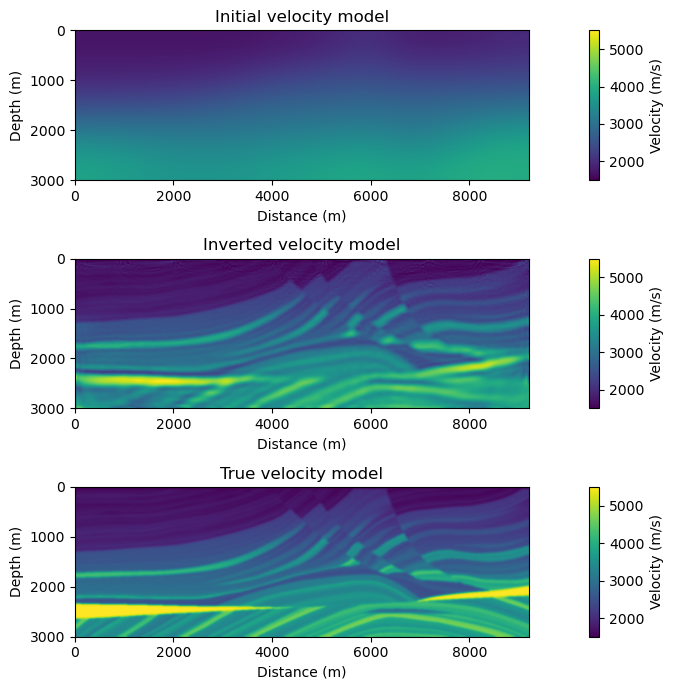

In [ ]:
# PLOTTING THE RESULTS OF THE LOCAL INVERSION

# Velocity limits used for plotting
vmin = v_true.min()
vmax = v_true.max()

# Plot
fig1, ax1 = plt.subplots(3, figsize=(7, 7))
im0 = ax1[0].imshow(v_init.cpu().T, aspect='auto', cmap='viridis',
             vmin= vmin, vmax=vmax, extent=extent)
ax1[0].set_title("Initial velocity model")
ax1[0].set_xlabel("Distance (m)")
ax1[0].set_ylabel("Depth (m)")
fig1.colorbar(im0, ax = ax1[0], shrink = 1, aspect = 15, pad = 0.1, label='Velocity (m/s)' )

im1 = ax1[1].imshow(v1.detach().cpu().T, aspect='auto', cmap='viridis',
             vmin= vmin, vmax=vmax, extent=extent)
ax1[1].set_title(f"Inverted velocity model")
ax1[1].set_xlabel("Distance (m)")
ax1[1].set_ylabel("Depth (m)")
fig1.colorbar(im1, ax = ax1[1], shrink = 1, aspect = 15, pad = 0.1, label='Velocity (m/s)' )

im2 = ax1[2].imshow(v_true.cpu().T, aspect='auto', cmap='viridis',
             vmin= vmin, vmax=vmax, extent=extent)
ax1[2].set_title("True velocity model")
ax1[2].set_xlabel("Distance (m)")
ax1[2].set_ylabel("Depth (m)")
fig1.colorbar(im2, ax = ax1[2], shrink = 1, aspect = 15, pad = 0.1, label='Velocity (m/s)' )

plt.tight_layout()
# plt.savefig("result_fwi_marmousi.png", dpi=300)  # uncomment to save the result


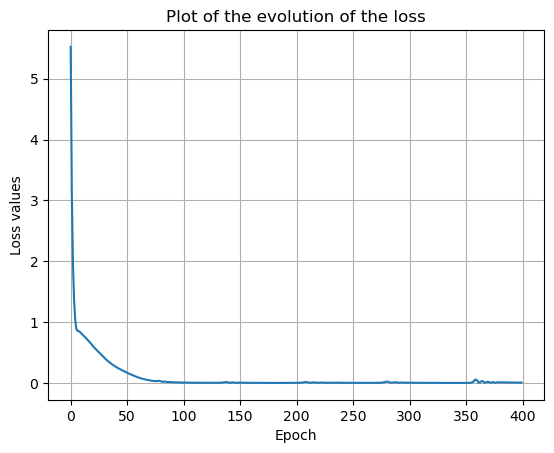

In [8]:
#PLOT THE LOSS VALUES
plt.figure()
plt.plot(losses)
plt.title("Plot of the evolution of the loss")
plt.xlabel("Epoch")
plt.ylabel("Loss values")
plt.grid()
plt.show()


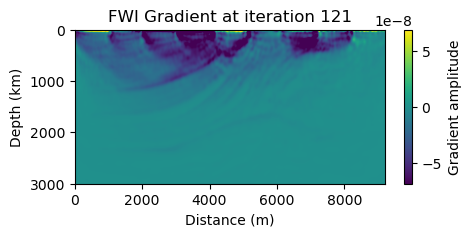

In [9]:
#PLOT OF THE GRADIENTS

k = np.random.randint(n_epochs)
plt.figure(figsize=(5, 2))
plt.imshow(gradients[k].cpu().T, cmap='viridis', aspect='auto', extent=extent)
plt.title(f"FWI Gradient at iteration { k+ 1}")
plt.xlabel("Distance (m)")
plt.ylabel("Depth (km)")
plt.colorbar(label='Gradient amplitude')
plt.show()